This Note has been made By Matias.S.  Student ID X9739682

The notebook is intendent to analyce bankruptcy data and create ML model that can predict the probability of a banktrupcy for a given company.
First we analyze and decscripe the data using statistics. Then we divide tha data according the 80/20 rule for creating the machine learning model and leave 20% for testing it. 
Then we analyce the effectivenes of the attributes in predicting the banktprutcy by plotting the using Seaborn & Matplotlib.

The dataset is about bankruptcy prediction of Polish companies. The data was collected from Emerging Markets Information Service (EMIS), which is a database containing information on emerging markets around the world. The bankrupt companies were analyzed in the period 2000-2012, while the still operating companies were evaluated from 2007 to 2013. Dataset contains varius financial attributes which measure, sales, capital structure, size, leverage % liquidity, margins, efficiency and other factors. Explanation for each attribute can be found on the Kaggle page or from my code in the next box where I will rename them.

In [10]:
#First we import all the necessary libraries.
import numpy as np #importing numpy for numerical operations
import pandas as pd #importing pandas for data manipulation
import matplotlib.pyplot as plt #importing matplotlib for data visualization
import seaborn as sns #importing seaborn for data visualization
import scipy.stats as stats #importing scipy for statistical functions
import xgboost as xgb #importing xgboost for extreme gradient boosting model
from sklearn.model_selection import train_test_split, GridSearchCV #importing sklearn model selection for train test split and hyperparameter tuning
from sklearn.metrics import classification_report, f1_score, roc_auc_score, confusion_matrix, precision_recall_fscore_support, accuracy_score, precision_score, recall_score, ConfusionMatrixDisplay #importing sklearn model selection and metrics for model evaluation
from sklearn.linear_model import LogisticRegression #importing sklearn linear model for logistic regression
from sklearn.preprocessing import StandardScaler #importing sklearn preprocessing for scaling data
from sklearn.pipeline import Pipeline #importing sklearn for machine learning tasks
from math import ceil #importing math for mathematical functions

df = pd.read_csv("bankruptcy_Train.csv") #loading the dataset
rename_dict = { #creating a dictionary to rename the columns for better understanding
    "Attr1":  "attr1_net_profit_total_assets", "Attr2":  "attr2_total_liabilities_total_assets", "Attr3":  "attr3_working_capital_total_assets", "Attr4": 
    "attr4_current_assets_short_term_liabilities","Attr5":  "attr5_liquid_assets_opex_minus_depr_365",  "Attr6":  "attr6_retained_earnings_total_assets",
    "Attr7":  "attr7_ebit_total_assets", "Attr8":  "attr8_book_equity_total_liabilities","Attr9":  "attr9_sales_total_assets","Attr10": "attr10_equity_total_assets", 
    "Attr11": "attr11_gp_extra_finexp_total_assets", "Attr12": "attr12_gross_profit_short_term_liabilities", "Attr13": "attr13_gp_plus_depr_sales", 
    "Attr14": "attr14_gp_plus_interest_total_assets", "Attr15": "attr15_total_liabilities_365_gp_plus_depr",  "Attr16": "attr16_gp_plus_depr_total_liabilities",
    "Attr17": "attr17_total_assets_total_liabilities",  "Attr18": "attr18_gross_profit_total_assets","Attr19": "attr19_gross_profit_sales", "Attr20": "attr20_inventory_365_sales",
    "Attr21": "attr21_sales_n_over_sales_n1", "Attr22": "attr22_operating_profit_total_assets",  "Attr23": "attr23_net_profit_sales", "Attr24": "attr24_gp_3y_total_assets",
    "Attr25": "attr25_equity_minus_share_capital_total_assets","Attr26": "attr26_net_profit_plus_depr_total_liabilities",  "Attr27": "attr27_operating_profit_financial_expenses","Attr28": "attr28_working_capital_fixed_assets",
    "Attr29": "attr29_log_total_assets","Attr30": "attr30_total_liabilities_minus_cash_sales","Attr31": "attr31_gp_plus_interest_sales","Attr32": "attr32_current_liabilities_365_cogs", 
    "Attr33": "attr33_operating_expenses_short_term_liabilities","Attr34": "attr34_operating_expenses_total_liabilities","Attr35": "attr35_profit_on_sales_total_assets","Attr36": "attr36_total_sales_total_assets",
    "Attr37": "attr37_curr_assets_minus_inventory_long_term_liabilities","Attr38": "attr38_constant_capital_total_assets","Attr39": "attr39_profit_on_sales_sales",
    "Attr40": "attr40_curr_assets_minus_inv_minus_recv_st_liabilities","Attr41": "attr41_total_liabilities_over_oper_profit_plus_depr_12_365","Attr42": "attr42_operating_profit_sales",
    "Attr43": "attr43_receivables_rotation_plus_inventory_turnover_days","Attr44": "attr44_receivables_365_sales","Attr45": "attr45_net_profit_inventory",
    "Attr46": "attr46_curr_assets_minus_inventory_st_liabilities","Attr47": "attr47_inventory_365_cogs","Attr48": "attr48_ebitda_total_assets",
    "Attr49": "attr49_ebitda_sales","Attr50": "attr50_current_assets_total_liabilities","Attr51": "attr51_short_term_liabilities_total_assets",
    "Attr52": "attr52_short_term_liabilities_365_cogs","Attr53": "attr53_equity_fixed_assets","Attr54": "attr54_constant_capital_fixed_assets",
    "Attr55": "attr55_working_capital","Attr56": "attr56_gross_margin_sales","Attr57": "attr57_adj_curr_assets_over_sales_minus_gp_minus_depr",
    "Attr58": "attr58_total_costs_total_sales","Attr59": "attr59_long_term_liabilities_equity","Attr60": "attr60_sales_inventory","Attr61": "attr61_sales_receivables",
    "Attr62": "attr62_short_term_liabilities_365_sales","Attr63": "attr63_sales_short_term_liabilities","Attr64": "attr64_sales_fixed_assets",
    "class": "bankrupt"   # 0 = no, 1 = yes
}
df = df.rename(columns=rename_dict) #renaming the columns using a dictionary for better understanding
df = df.replace([np.inf, -np.inf], np.nan) # replace infinite values with NaN
X = df.drop(columns=["bankrupt"]) # feature variables
y = df["bankrupt"] # target variable, to be removed from feature set

# basic stats: stats = rows, variables = columns
desc = df.describe() # get basic descriptive statistics, mean, std, min, max, percentiles 25, 50, 75

desc.loc["missing_count"] = df.isna().sum()
desc.loc["missing_pct"] = (df.isna().mean() * 100).round(2) # percentage of missing values, rounded to 2 decimals
desc.loc["num_zero"] = (df == 0).sum() # count of zero values
desc.loc["num_negative"] = (df < 0).sum() # count of negative values
desc # display the descriptive statistics

,attr1_net_profit_total_assets,attr2_total_liabilities_total_assets,attr3_working_capital_total_assets,attr4_current_assets_short_term_liabilities,attr5_liquid_assets_opex_minus_depr_365,attr6_retained_earnings_total_assets,attr7_ebit_total_assets,attr8_book_equity_total_liabilities,attr9_sales_total_assets,attr10_equity_total_assets,...,attr56_gross_margin_sales,attr57_adj_curr_assets_over_sales_minus_gp_minus_depr,attr58_total_costs_total_sales,attr59_long_term_liabilities_equity,attr60_sales_inventory,attr61_sales_receivables,attr62_short_term_liabilities_365_sales,attr63_sales_short_term_liabilities,attr64_sales_fixed_assets,bankrupt
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.007954,-0.007140,-0.003544,0.005005,-0.004687,0.001455,-0.006963,0.009053,0.006763,0.007456,...,0.009804,0.005208,-0.009751,-0.002655,0.004548,0.014331,-0.006864,0.020750,-0.003984,0.020300
std,1.396405,1.409440,1.015494,0.908020,1.394750,1.286713,1.412509,1.064426,1.171199,1.407349,...,0.017370,0.718682,0.026124,0.467139,1.252571,1.171160,0.277288,1.115182,0.930875,0.141032
min,-9.474787,-140.604555,-25.597146,-0.381641,-138.720013,-26.249562,-141.176615,-0.966015,-1.294340,-2.528495,...,-1.657288,-42.381245,-0.037484,-3.218490,-0.048598,-0.412525,-0.022204,-0.743297,-0.050969,0.000000
25%,-0.079776,-0.055604,-0.516971,-0.192306,0.006798,-0.016047,-0.008018,-0.445667,-0.388184,-0.068584,...,0.009315,0.003199,-0.010766,-0.022740,-0.043418,-0.221237,-0.016847,-0.371384,-0.041603,0.000000
50%,-0.019204,0.000246,0.003186,-0.117972,0.007302,-0.016047,0.004280,-0.260150,-0.307842,0.000253,...,0.009838,0.010013,-0.009924,-0.020438,-0.039928,-0.139653,-0.013821,-0.180311,-0.034319,0.000000
75%,0.081218,0.056957,0.585722,0.022705,0.007753,0.016026,0.024222,0.098874,0.156638,0.070036,...,0.010693,0.019900,-0.009416,-0.014401,-0.031820,-0.002210,-0.009476,0.133244,-0.020507,0.000000
max,137.557872,2.004925,3.324327,60.825460,11.556238,121.354736,0.623095,47.504463,62.936396,140.123299,...,0.036727,37.405312,2.551674,27.969785,117.341069,59.139158,23.970250,62.527240,90.774695,1.000000
missing_count,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
missing_pct,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


Most common descriptive statistics by attribute. We also can see that the data has no missing values. We also can see that out of 10 000 compies 9797 survived and 203 went bust. Next lets show that on piechart.

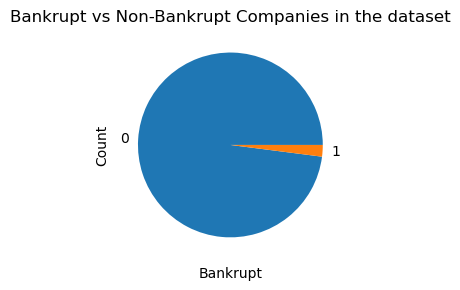

bankrupt
0    9797
1     203
Name: count, dtype: int64


In [11]:
plt.figure(figsize=(3,3))
df["bankrupt"].value_counts().plot(kind='pie') #Shwowing the distribution of bankrupt vs non-bankrupt companies in the dataset as pie chart
plt.xlabel("Bankrupt")
plt.title("Bankrupt vs Non-Bankrupt Companies in the dataset")
plt.ylabel("Count")
plt.show(); print(bankrupt_counts := df["bankrupt"].value_counts())

Financial data can be be analyzed in many ways. Next we will group the data into four parts. Each group will tells us the story of the target company but from a slightly diffent angle. The groups are related to: sales, profitability, working capital & capital structure.


In [ ]:
#I have pivoted away from the normal coding style of one feature per line to group features more compactly.
sales_cols = [ # Defining groups of features based on financial. This one is ratios related to sales
    "attr9_sales_total_assets","attr13_gp_plus_depr_sales","attr19_gross_profit_sales","attr20_inventory_365_sales","attr21_sales_n_over_sales_n1",
    "attr30_total_liabilities_minus_cash_sales","attr31_gp_plus_interest_sales", "attr36_total_sales_total_assets","attr39_profit_on_sales_sales","attr42_operating_profit_sales",
    "attr43_receivables_rotation_plus_inventory_turnover_days","attr44_receivables_365_sales","attr56_gross_margin_sales","attr58_total_costs_total_sales",
    "attr60_sales_inventory","attr61_sales_receivables","attr62_short_term_liabilities_365_sales","attr63_sales_short_term_liabilities","attr64_sales_fixed_assets",]
profitability_cols = [ # same byt for profitability ratios
    "attr1_net_profit_total_assets", "attr6_retained_earnings_total_assets","attr7_ebit_total_assets","attr11_gp_extra_finexp_total_assets","attr14_gp_plus_interest_total_assets",
    "attr18_gross_profit_total_assets","attr22_operating_profit_total_assets","attr23_net_profit_sales","attr24_gp_3y_total_assets","attr26_net_profit_plus_depr_total_liabilities",
    "attr27_operating_profit_financial_expenses","attr35_profit_on_sales_total_assets","attr45_net_profit_inventory","attr48_ebitda_total_assets","attr49_ebitda_sales",]
working_capital_cols = [ # same byt for working capital ratios
    "attr3_working_capital_total_assets","attr4_current_assets_short_term_liabilities","attr5_liquid_assets_opex_minus_depr_365","attr20_inventory_365_sales","attr28_working_capital_fixed_assets",
    "attr37_curr_assets_minus_inventory_long_term_liabilities","attr40_curr_assets_minus_inv_minus_recv_st_liabilities","attr46_curr_assets_minus_inventory_st_liabilities","attr47_inventory_365_cogs","attr50_current_assets_total_liabilities",
    "attr52_short_term_liabilities_365_cogs","attr55_working_capital","attr57_adj_curr_assets_over_sales_minus_gp_minus_depr",]
capital_structure_cols = [ # same byt for capital structure ratios
    "attr2_total_liabilities_total_assets","attr8_book_equity_total_liabilities","attr10_equity_total_assets","attr15_total_liabilities_365_gp_plus_depr","attr16_gp_plus_depr_total_liabilities",
    "attr17_total_assets_total_liabilities","attr25_equity_minus_share_capital_total_assets","attr29_log_total_assets","attr30_total_liabilities_minus_cash_sales","attr32_current_liabilities_365_cogs",
    "attr33_operating_expenses_short_term_liabilities","attr34_operating_expenses_total_liabilities","attr38_constant_capital_total_assets","attr41_total_liabilities_over_oper_profit_plus_depr_12_365",
    "attr51_short_term_liabilities_total_assets","attr53_equity_fixed_assets","attr54_constant_capital_fixed_assets","attr59_long_term_liabilities_equity"]
group_defs = { # dictionary to hold the groups of features, for easier access later
    "Sales": sales_cols,# sales related ratios
    "Profitability": profitability_cols, # profitability related ratios
    "Working_capital": working_capital_cols, # working capital related ratios
    "Capital_structure": capital_structure_cols, # capital structure related ratios
}
scaler = StandardScaler()
df_std = pd.DataFrame(
    scaler.fit_transform(df[group_defs["Sales"] #using StandardScaler to standardize the features (z-score normalization)
                           + group_defs["Profitability"] # combining all groups of features and naming the columns and indexs accordingly
                           + group_defs["Working_capital"]  # -||-
                           + group_defs["Capital_structure"]]), # -||-
    columns=(group_defs["Sales"] #setting the column names
             + group_defs["Profitability"]
             + group_defs["Working_capital"]
             + group_defs["Capital_structure"]),
    index=df.index, #setting the index to be the same as the original dataframe
)
group_score_dict = {} # calculate mean z-score for each group
for name, cols in group_defs.items(): # iterate over groups
    group_score_dict[name] = df_std[cols].mean(axis=1) # calculate mean z-score for each group
group_scores = pd.DataFrame(group_score_dict) # convert to DataFrame
group_scores["bankrupt"] = df["bankrupt"] # add target variable back in


Lets do a correlation matrix for each group.

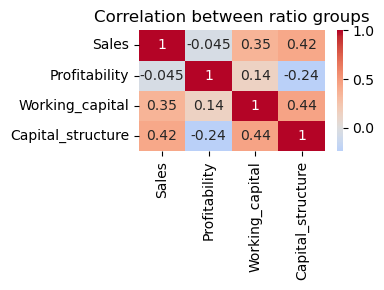

In [4]:
plt.figure(figsize=(4, 3)) # plot heatmap of correlations between group scores, setting figure size
sns.heatmap(group_scores.drop(columns="bankrupt").corr(), # drop target variable for correlation
            annot=True, center=0, cmap="coolwarm") # plot heatmap with annotations, centered at 0, using coolwarm colormap
plt.title("Correlation between ratio groups") # add title to the plot and 
plt.tight_layout() # adjust layout to fit everything nicely
plt.show() # display the plot


The group-level correlations show that Sales is almost unrelated to Profitability (–0,045), but moderately positively related to Working capital (0,35) and Capital structure (0,42). So higher sales go with more working capital and a larger capital base, but not automatically with higher profits.

Profitability is slightly higher in firms with stronger Working capital (0,14) and somewhat lower in firms with heavier Capital structure (–0,24). Working capital and Capital structure are moderately correlated (0,44), meaning firms with more working capital also tend to be more capital-intensive. Overall, the groups capture related but clearly distinct dimensions. We might use these findingss later. 

Now next we need to winsorize the data in order to remove clear outliers. In financial data where we are predicting financial distress its important to make sure we dont remove too much data. Therefore we will use data thats between 2,5% and 97,5% limits. Its good to know that data is VERY UNBALANCED. Only about 2% of the companies went banktrupt. Next up lets divide the data in to four groups (Sales, profitability, working capital & capitall structure) and anylyze it a bit furher. 

In [5]:
def winsorointi_w(df, cols, lower=0.025, upper=0.975):
    df_w = df.copy()
    for c in cols:
        lo = df_w[c].quantile(lower)
        hi = df_w[c].quantile(upper)
        df_w[c] = df_w[c].clip(lo, hi)
    return df_w

In [6]:
attributes = df.columns.drop("bankrupt")   # pick up all attribute columns except the target column bankrupt
df_w = winsorointi_w(df, cols=attributes)  # Makes a copy of the dataframe with winsorized values named df_w, also ensures all columns are included except target (bankrupt).
df_viz = df_w.copy() # create a copy of the winsorized dataframe for visualization
df_viz["status"] = df_viz["bankrupt"].map({0: "Survived", 1: "Bankrupt"}) # mapping the bankrupt column to status column for better visualization

In [7]:
def plot_hist_grid(df, attrs, cols=2, bins=40):
    """
    Piirtää histogrammit valituille attribuuteille gridinä.
    Jokaisessa subplotissa Survived vs Bankrupt eri väreillä.
    """
    n = len(attrs) # number of attributes
    rows = ceil(n / cols) # number of rows needed

    fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*4)) # create subplots and sets the figure size
    axes = np.atleast_1d(axes).flatten() # flatten the axes array to 1D for easy indexing

    for ax, attr in zip(axes, attrs): # iterate through attributes and corresponding axes
        sns.histplot( #plot type
            data=df, # dataframe to use
            x=attr, # attribute to plot
            hue="status",         # Survived vs Bankrupt
            bins=bins,
            kde=True,
            stat="density",
            common_norm=False,
            ax=ax
        )
        ax.set_title(attr)
        ax.set_xlabel("")       # ettei toistu turhaan
        ax.set_ylabel("")
    for j in range(len(attrs), len(axes)): 
        fig.delaxes(axes[j]) #

    fig.tight_layout() # adjust layout to prevent overlap
    plt.show() # show the plot

Now once the date has been windsorized lets look at histograms of few selested variables: gross profit + depreciation / total liabilities, net profit + depreciation / total liabilities, working capital / total assets and profit on sales / total assets. Those fours should give some what relewant overwiev of the companies currect standings.

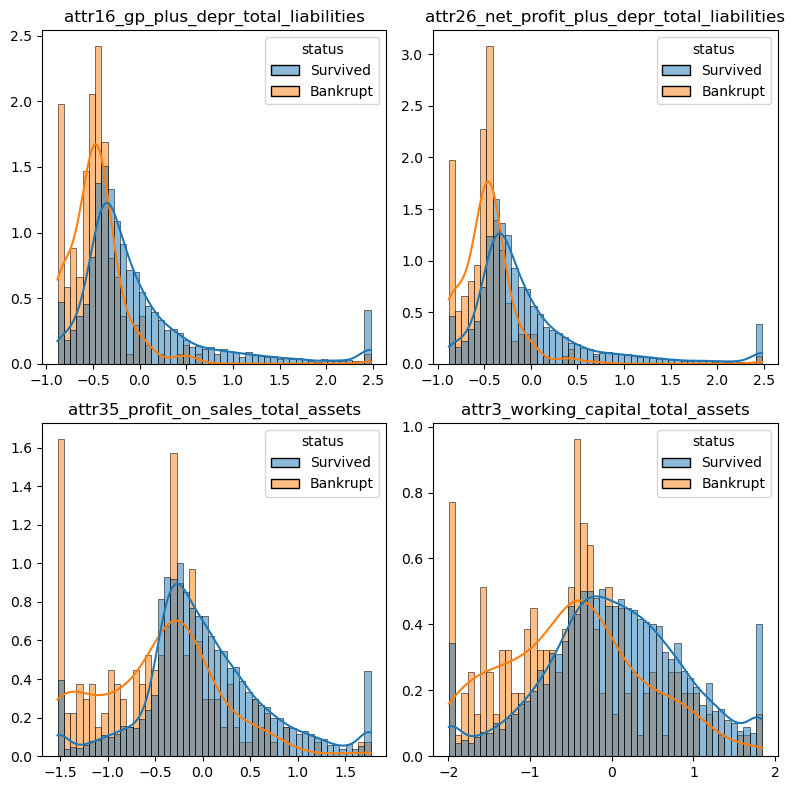

In [8]:
vars_pair =[
    "attr16_gp_plus_depr_total_liabilities",
    "attr26_net_profit_plus_depr_total_liabilities",
    "attr35_profit_on_sales_total_assets",
    "attr3_working_capital_total_assets",]
plot_hist_grid(df_viz, vars_pair, cols=2, bins=50)

I plotted histograms (with density curves)  four financial ratios, split by status (bankrupt vs survived). Most variables are clearly non-normally distributed ( attr3 is some what normally distributed). They are highly skewed and have heavy tails with some extreme outliers (even after windsorizing).

All four plots tell the same story: bankrupt firms sit clearly on the “worse” side of each ratio.

For attr16 and attr26 ((gp or net profit + depr) / total liabilities) the bankrupt density is shifted left, with many more strongly negative values and almost no high positive values, while survivors have a thicker right tail → they generate more profit relative to their debt.
For attr35 (profit on sales / total assets) bankrupt firms again concentrate in the loss-making region, survivors are closer to zero with some positive cases.
For attr3 (working capital / total assets) bankrupt firms are heavily skewed to strongly negative working capital, whereas survivors are closer to zero and more often positive.

So these key profitability and working-capital ratios all visually separate bankrupt from healthy firms: bankrupt companies have persistently negative earnings relative to liabilities and assets, and chronically insufficient working capital.

In next step I take four continuous financial ratios (working capital, costs/sales, long-term debt/equity and inventory turnover) and **bin** each of them into four equally sized groups (quartiles: Low, Medium, High, Very High). For every quartile I then calculate the **percentage of bankrupt vs. healthy firms** using a crosstab. This converts the raw ratios into an easy-to-read form:  
“Given that a firm belongs to this quartile of the ratio, what is its observed bankruptcy rate?”

The goal is to see whether higher or lower levels of each ratio are systematically linked with higher bankruptcy probabilities, and to quantify how strong those differences are before we move to multivariate machine learning models.

In [ ]:
# Create quartile bins for four key ratios before doing the crosstab
df_w["wc_bin"] = pd.qcut(df_w["attr3_working_capital_total_assets"], 4, labels=["Low", "Medium", "High", "Very High"])
df_w["cost_to_sales_bin"] = pd.qcut(df_w["attr58_total_costs_total_sales"], 4, labels=["Low", "Medium", "High", "Very High"])
df_w["ltde_bin"] = pd.qcut(df_w["attr59_long_term_liabilities_equity"], 4, labels=["Low", "Medium", "High", "Very High"])
df_w["inv_turn_bin"] = pd.qcut(df_w["attr60_sales_inventory"], 4, labels=["Low", "Medium", "High", "Very High"])

bin_cols = { # Mapping: existing bin columns -> nice labels
    "wc_bin": "Working capital",
    "cost_to_sales_bin": "Costs / sales",
    "ltde_bin": "LT debt / equity",
    "inv_turn_bin": "Inventory turnover",
}
tables = []  # we collect small tables here
for col, nice_name in bin_cols.items():
    ct = pd.crosstab(    # Crosstab: bankruptcy % in each bin of this variable
        df_w[col],
        df_w["bankrupt"],
        normalize="index"
    ) * 100
    ct["Variable"] = nice_name  # Add metadata columns so we can stack them later
    ct["Bin"] = ct.index

    tables.append(ct.reset_index(drop=True)) # Reset index so Bin becomes a normal column

summary_bins = pd.concat(tables, ignore_index=True) # Concatenate all mini-tables into one summary table
summary_bins = summary_bins.rename(columns={0: "Healthy_%", 1: "Bankrupt_%"}) # Rename columns 0 and 1 to something readable
print("Rows in summary_bins:", len(summary_bins)) # Sanity check: how many rows do we have?
summary_bins # Show the final compact table


KeyError: 'wc_bin'

Table summarizes bankruptcy rates when four key ratios are split into quartiles (Low…Very High). For **working capital**, the pattern is very clear and monotonic: firms in the lowest quartile have a bankruptcy rate of about **3,6 %**, while in the highest quartile the rate drops below **1 %**. In relative terms, the probability of bankruptcy is roughly four times higher for firms with the weakest working capital compared to those with the strongest position. This strongly supports the view that weak short-term liquidity is a core driver of financial distress.

For **costs / sales** and **long-term debt / equity**, the highest bankruptcy rates are observed in the **Very High** quartiles (around **3,2–3,3 %**), whereas the lower and middle quartiles cluster closer to **1–2 %**. In other words, both very high cost intensity and very high structural leverage are associated with clearly elevated bankruptcy risk, even though the relationship is not as perfectly monotonic as with working capital.

The pattern for **inventory turnover** is weaker but still visible: the **Low** turnover quartile has a bankruptcy rate of about **3,1 %**, while the other three quartiles are closer to **1,6–1,8 %**. This suggests that inefficient use of inventory is correlated with distress, but its effect size appears smaller than that of working capital or leverage.

Overall, these univariate results indicate that **poor liquidity (low working capital), high cost intensity and high leverage** systematically coincide with higher bankruptcy probabilities. 

Next we should calculate (SMD) Standized mean diffence, which shows how much the average value of each atribute differs on banktrupt companies vs non bankrut. Values close to 0 mean the ratio has almost the same mean in both groups, while large positive (negative) values mean that bankrupt firms have much higher (lower) values of that ratio. SMD gives us insights which variables to choose for the ML algorhytms.

In [ ]:
num_cols = df_w.columns.drop(["bankrupt", "wc_bin", "cost_to_sales_bin", "ltde_bin", "inv_turn_bin"]) # Next we calculate the Standardized Mean Difference (SMD) for each attribute to quantify the effect size between bankrupt and non-bankrupt companies.
group_means = df_w.groupby("bankrupt")[num_cols].mean() #    calculate group means
group_stds  = df_w.groupby("bankrupt")[num_cols].std() #    calculate group standard deviations
mean_diff  = group_means.loc[1] - group_means.loc[0]      # bankrupt=1 - nonbankrupt=0
pooled_std = np.sqrt((group_stds.loc[1]**2 + group_stds.loc[0]**2) / 2) #calculate pooled standard deviation
smd = mean_diff / pooled_std #calculate SMD
smd_sorted = smd.abs().sort_values(ascending=False) #sorts the SMD values in descending order based on absolute values
print(smd_sorted.head(4)) #prints the top 4 attributes with highest Standardized Mean Difference (SMD) values.

num_cols = df_w.columns.drop(["bankrupt", "wc_bin", "cost_to_sales_bin", "ltde_bin", "inv_turn_bin"])  #draw SMD values as scatter plot

group_means = df_w.groupby("bankrupt")[num_cols].mean() #calculate group means
group_stds  = df_w.groupby("bankrupt")[num_cols].std() #calculate group standard deviations
mean_diff  = group_means.loc[1] - group_means.loc[0] #calculate mean difference between bankrupt and non-bankrupt
pooled_std = np.sqrt((group_stds.loc[1]**2 + group_stds.loc[0]**2) / 2) #calculate pooled standard deviation
smd = mean_diff / pooled_std #calculate SMD
smd_sorted = smd.sort_values() #sorts the SMD values in ascending order
plt.figure(figsize=(6, 10)) #figure size
plt.axvline(0, linestyle="--")  # Comparison line in the midlle of the plot.
plt.scatter(smd_sorted, smd_sorted.index)
plt.xlabel("Standardized mean difference (SMD)") #x-axis label
plt.ylabel("Attribute") #y-axis label
plt.title("Effect sizes: Survived vs Bankrupt") #set the title of the plot
plt.tight_layout() #ensures tight layout
plt.show() # display the plot

smd_abs = smd.abs() # take absolute value, sort, pick top 15, we can use the top 15 attributes for ML modelling later.
top15 = (
    smd_abs
    .sort_values(ascending=False)   # ✅ no column name here
    .head(15)
    .index
    .intersection(df_w.columns)
    .tolist()
)
top15 = [c for c in top15 if c in df_w.columns]# make sure they actually exist in df_w (just in case)


The plot reveals that the largest positive SMDs are mainly capital-structure and liability ratios (e.g. total liabilities / total assets, short-term liabilities / total assets), indicating that bankrupt firms are systematically more leveraged. The largest negative SMDs are mostly profitability and equity ratios (e.g. net profit / total assets, profit on sales, equity minus share capital / total assets), meaning that bankrupt firms are much less profitable and have a weaker equity base. Ratios with SMDs near zero contribute little to distinguishing the two classes.

For the ML model this plot is useful in three ways:

It identifies which features carry the strongest signal for bankruptcy (high |SMD|), so they are natural candidates to include and to pay attention to when interpreting the model.
It suggests that many of the strong predictors come from the same groups (profitability, capital structure, working capital), indicating correlation and redundancy, which supports using regularisation or careful feature selection. It provides a sanity check for the model coefficients: in a logistic regression, for example, we expect positive weights for high-SMD leverage ratios and negative weights for high-SMD profitability/equity ratios, matching the direction of the SMDs.

Next we move on to the prediction part of the assignment. In the first part we will be usinf ML model called XBGclassier, which is a machine-learning model that builds an ensemble of many small decision trees using gradient boosting, allowing it to capture complex nonlinear patterns and usually giving very strong performance on structured/tabular data.  We are using Windsorized data and the model uses all attributes, and decides independetly what is important.

In [ ]:
def Train_ml_model(df_w): #defining a function to train the machine learning model  
    bin_columns = ["wc_bin", "cost_to_sales_bin", "ltde_bin", "inv_turn_bin"]
    drop_cols = ["bankrupt"] + [c for c in bin_columns if c in df_w.columns]
    X = df_w.drop(columns=drop_cols)   # features & target
    y = df_w["bankrupt"]  # target
    X_train, X_test, y_train, y_test = train_test_split(  # train / test split, imported from sklearn
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y,)
    model = xgb.XGBClassifier( # model
        eval_metric="logloss", # evaluation metric for the model, which means how accurate your predicted probabilities are.
    )
    model.fit(X_train, y_train)  # probabilities for class 1 (bankrupt) on test set
    y_proba = model.predict_proba(X_test)[:, 1] # get probabilities for class 1
    plt.figure(figsize=(10, 6)) # plot feature importance and sets figure size
    xgb.plot_importance(model, max_num_features=20) # plot feature importance setting maximum number of features to 20
    plt.title("Feature importance") #title of the plot
    plt.show() # display the plot
    return model, X_test, y_test, y_proba


In [ ]:
model, X_test, y_test, y_proba = Train_ml_model(df_w)

Feature importance shows which atrributes our model values. Those with higher scores will have bigger impact in the model. Lets plot the results in confusion matrix.

In [ ]:
thresholds = [0.5, 0.4, 0.3, 0.25, 0.2] #a tupple of different thresholds to evaluate

n = len(thresholds) #Goal is to create photo grid of all confusion matrixes in one image
cols = 3
rows = ceil(n / cols)
fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows)) # create subplots for the confusion matrixes and sets the figure size
axes = np.atleast_1d(axes).flatten()
for ax, thr in zip(axes, thresholds):
    y_pred_thr = (y_proba >= thr).astype(int)
    cm = confusion_matrix(y_test, y_pred_thr, labels=[0, 1])
    disp = ConfusionMatrixDisplay( #displaying the confusion matrix for each threshold
        confusion_matrix=cm,
        display_labels=["Survived", "Bankrupt"]) #labels
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"threshold = {thr}")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
#hide extra axes if/when threshold list doesn't fill the whole grid
for j in range(len(thresholds), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
#tight table of metrics at different thresholds
rows_table = []
for thr in thresholds:
    y_pred_thr = (y_proba >= thr).astype(int)

    cm = confusion_matrix(y_test, y_pred_thr, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred_thr, labels=[1], average=None
    )
    acc = accuracy_score(y_test, y_pred_thr)
    rows_table.append({
        "threshold": thr,
        "TN": tn, #True Negatives means correctly predicted non-bankrupt companies
        "FP": fp, #False Positives means incorrectly predicted bankrupt companies
        "FN": fn, #False Negatives means incorrectly predicted non-bankrupt companies
        "TP": tp, #True Positives means correctly predicted bankrupt companies
        "precision_1": precision[0],
        "recall_1": recall[0],
        "f1_1": f1[0],
        "accuracy": acc,
    })
results = pd.DataFrame(rows_table)
results_rounded = results.copy()
for col in ["precision_1", "recall_1", "f1_1", "accuracy"]:
    results_rounded[col] = results_rounded[col].round(3)
results_rounded

TN True Negatives means correctly predicted non-bankrupt companies, FP False Positives means incorrectly predicted bankrupt companies, FN False Negatives means incorrectly predicted non-bankrupt companies
TP True Positives means correctly predicted bankrupt companies.

The analysis model is somewhat working the problem is that the data is very heavily skewed to one side (Survived), therefore we need to make some adjustments because right now we only predict 27% of bankrupts. (11/11+30=0,27).
The model only flags were strong signals thats why we have only 2 false positives. We need to lower the prediction hurdl

I would choose 0,2 as the threshold value, due to it having the best out detection ratio, but still we can clearly see that with the current model (XGBoost). We cant really predict financial distress that reliably, because we miss so many banktruptcies Even rotating diffenrent thresholds for the predictions does not really help. Best we can do is to predict 11 out of 41 bankruptcies. Allthough the accuracy of the model is high, its really not working. A high accuracy is due to tho model being able to know that a company survives, which does not realyl interest us. We must choose another ML model. Lets try logistic regression. Here the previously calculated SMD values might come in handy. 

In [ ]:
def Train_logit_model(df_w, feature_cols): #defining a function to train logistic regression model, only using selected attributes as predictors.
    X = df_w[feature_cols].copy()
    y = df_w["bankrupt"].astype(int)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y,
    )
    logit = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
        )),
    ])
    logit.fit(X_train, y_train)
   
    y_proba = logit.predict_proba(X_test)[:, 1]  # probabilities for class 1 (bankrupt)
    return logit, X_test, y_test, y_proba

In [ ]:
def evaluate_thresholds(y_test, y_proba, thresholds): #for each threshold, compute confusion matrix parts and metrics returns a DataFrame.
    rows = []
    for thr in thresholds:
        y_pred = (y_proba >= thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()

        precision = precision_score(y_test, y_pred, zero_division=0)
        recall    = recall_score(y_test, y_pred, zero_division=0)
        f1        = f1_score(y_test, y_pred, zero_division=0)
        acc       = accuracy_score(y_test, y_pred)

        rows.append({
            "threshold": thr,
            "TN": tn, "FP": fp, "FN": fn, "TP": tp,
            "precision_1": precision,
            "recall_1": recall,
            "f1_1": f1,
            "accuracy": acc
        })
    return pd.DataFrame(rows)

In [ ]:
def plot_confusion_subplots(y_test, y_proba, thresholds, n_rows=2, n_cols=3): #plots a grid of confusion matrices for different thresholds
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
    axes = axes.ravel()

    for i, thr in enumerate(thresholds):
        if i >= len(axes):
            break

        ax = axes[i]
        y_pred = (y_proba >= thr).astype(int)
        cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=["Survived", "Bankrupt"]
        )
        disp.plot(ax=ax, colorbar=False)
        ax.set_title(f"Threshold = {thr:.2f}")

    for j in range(len(thresholds), len(axes)):     # hide unused axes
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [ ]:
logit_model, X_test_logit, y_test_logit, y_proba_logit = Train_logit_model( # 1) train the model on winsorized data with SMD top-15
    df_w,
    top15
)
thresholds = [0.50, 0.40, 0.30, 0.25, 0.15, 0.10] #different thresholds to evaluate

results_logit = evaluate_thresholds(y_test_logit, y_proba_logit, thresholds) #shows the results dataframe for different thresholds
results_logit   # Jupyter will show the table nicely
# 4) subplot confusion matrices for all thresholds
plot_confusion_subplots(y_test_logit, y_proba_logit, thresholds, n_rows=2, n_cols=3) #plot confusion matrices for all thresholds
display(results_logit) #shows the results dataframe.

The logistic regression model clearly improves the recall of bankrupt firms compared to the XGBoost model (around 75–85 % vs. roughly 30 %). However, this comes at the cost of extremely low precision: at the 0,5  threshold (which i feel was the best), only about 5 % of firms predicted as ‘bankrupt’ actually go bankrupt, while the remaining 93–94 % are false alarms. Overall accuracy also drops from 98 % (XGBoost) to around 77 %.

In other words, the logistic model is much more aggressive in flagging firms as risky. This makes it unsuitable as a stand-alone credit decision tool, but it could be used as an early-warning system that generates a list of firms for further manual analysis. In its current form, the model should be interpreted as a screening tool that prioritises avoiding false negatives (missed bankruptcies) at the expense of a large number of false positives. As a screenin tool  perhaps for a credit instituttion this model would still be better because false negative is much worse than false positive. 

ChatGPT 5.0 was heavily utilized in code creation and debugging.